# 21_因果推断基础-回归调整与标准化

## Notebook 使用说明

建议先阅读《03. 因果图、混杂与识别假设》。本篇主案例需要 NumPy、pandas 和 Matplotlib，最后的二元结局练习还使用 statsmodels 拟合 Logistic 回归。缺少依赖时，可在当前 Python 环境安装：`python -m pip install numpy pandas matplotlib statsmodels`。

本篇主要依据参考资料 [1] 第 10.3–10.4 节与 [2] 第 5.2 节展开。三层汇总表、连续结局和二元结局数据均为按这些方法另设的教学构造，不是原书的实证数据；具体生成规则在对应案例中给出。

数据和图形都由本篇代码生成，不需要下载文件，也不依赖前面 Notebook 的变量或 `notebook_support.py`。主分析沿用第三篇的总体视角，目标为 $E[Y(1)-Y(0)]$；重复模拟会重新抽取研究对象。Bootstrap 同样按独立同分布的整行观察数据重抽样，不使用第二篇固定有限总体的随机化方差公式。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells；下文解释对应默认参数，修改参数后以新的输出为准。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
from pathlib import Path
from statistics import NormalDist

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS,
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)

SEED_DATA = 42
SEED_BOOT = 2026
SEED_REPEAT = 2027
SEED_BINARY = 2028
N_MAIN = 1800
N_BOOT = 999
N_REPEATS = 500
SAMPLE_SIZES = (300, 1200, 4800)
ALPHA = 0.05
Z_CRIT = NormalDist().inv_cdf(1 - ALPHA / 2)

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8


上一篇讨论了哪些变量应该调整。现在假设已经找到了合适的处理前变量，接下来怎么把它们用起来？

最熟悉的办法是拟合 `Y ~ T + X`，然后读出 `T` 的系数。但这个办法暗含了一个限制：相同的处理，对所有 $X$ 都产生同样大小的平均作用。加入交互项，或者把结局换成是否通过考试，处理系数就不再能直接当成总体平均效应。

回归调整有一种更通用的算法：保留同一批人的基础特征，分别预测他们接受处理与不接受处理时的结局，再把两种预测的差取平均。下面先用一张小表把这个过程算清楚，再扩展到连续变量、非线性关系和误差范围。

## 理论基础

### 1. 回归模型估计的是什么？

仍用 $T\in\{0,1\}$ 表示处理，$X$ 表示已经选定的处理前调整变量，$Y$ 表示结局。定义：

$$
\mu_t(x)=E[Y\mid T=t,X=x],\qquad t=0,1.
$$

$\mu_1(x)$ 是同类人接受处理时的平均结局，$\mu_0(x)$ 是同类人不接受处理时的平均结局。它们首先是观察数据中的条件均值，不是直接观察到的个体反事实。[1，第 10.3–10.4 节]

在处理定义清楚、无个体间干扰、观察结局满足一致性、条件可忽略性和重叠成立时：

$$
E[Y(t)\mid X=x]=E[Y\mid T=t,X=x]=\mu_t(x).
$$

因此，目标人群的平均处理效应可以写成：

$$
\tau=E[Y(1)-Y(0)]
=E_X[\mu_1(X)-\mu_0(X)].
$$

这是上一篇得到的调整公式，也称 g-formula。这里不重新证明，而是把它变成有限样本中的计算。[1，定理 10.1；2，定理 5.2.1]

### 2. 标准化：两种处理，都对同一群人求平均

先用观察数据估计两个条件均值，再计算：

$$
\widehat\tau_{\mathrm{reg}}
=\frac1n\sum_{i=1}^n
\{\widehat\mu_1(X_i)-\widehat\mu_0(X_i)\}.
$$

具体到代码，就是复制两份特征：一份把所有人的 `T` 设为 1，另一份设为 0，其他处理前特征保持不变。两份数据都只用于预测，不修改训练时的真实处理和真实结局。[1，第 10.4.2 节]

这和筛选两个实际组分别求平均不同。实际处理组与对照组可能有不同的 $X$ 分布；标准化使用相同的 $X_1,\ldots,X_n$。这里的“标准化”是统一目标人群构成，不是把特征变成均值 0、方差 1。

还要注意，$\widehat\mu_1(X_i)-\widehat\mu_0(X_i)$ 估计的是具有特征 $X_i$ 的人的条件平均效应。一般不能因为有了两列预测，就声称已经恢复了这个人真实的 $Y_i(1)-Y_i(0)$。[1，第 2.2、10.4.2 节]

### 3. 为什么有时读一个系数就够，有时不够？

先看加性模型：

$$
\mu_t(x)=\beta_0+\beta_Tt+\beta_Xx.
$$

两种处理相减后，$\beta_0$ 与 $\beta_Xx$ 抵消，所以 $\mu_1(x)-\mu_0(x)=\beta_T$，求平均仍是 $\beta_T$。在相应识别条件和这个模型成立时，处理系数确实就是 ATE。[1，第 10.4.2 节]

再加入交互项：

$$
\mu_t(x)=\beta_0+\beta_Tt+\beta_Xx+\beta_{TX}tx.
$$

这时：

$$
\mu_1(x)-\mu_0(x)=\beta_T+\beta_{TX}x,
\qquad
\widehat\tau_{\mathrm{reg}}=\widehat\beta_T+\widehat\beta_{TX}\bar X.
$$

单独的 $\widehat\beta_T$ 表示 $X=0$ 处的预测差，不一定是目标人群的平均差。若先按目标人群均值中心化 $X$ 再构造交互项，新的处理系数就与逐人预测后求平均一致。这只是同一个模型的重新参数化，不是换了因果问题。[1，第 10.4.2 节；2，第 5.2 节]

如果用 $X^2$ 等变换，还需要对这些进入交互的特征分别考虑。例如效应形式为 $\beta_T+\beta_{TX}X+\beta_{TX^2}X^2$，则平均效应为：

$$
\widehat\beta_T+\widehat\beta_{TX}\bar X
+\widehat\beta_{TX^2}\overline{X^2}.
$$

不能把 $\overline{X^2}$ 换成 $\bar X^2$。这也是“逐人预测再平均”和“只给一个平均特征的人预测”可能不同的原因。这个等式由上面的交互模型直接展开；下面会用数值核对。

## 完整案例一：从分层均值到回归预测

### 1. 先看一张三层汇总表

设 $T$ 表示是否参加辅导，$X$ 表示辅导前的基础类别，$Y$ 是后续成绩指标。下面是一张自行构造的教学表，数值单位为分。它只用来核对标准化的算术，不是实际调查结果。

假定基础类别是足够的调整变量，目标人群是表中全部 300 人。三类人各占三分之一，但较高基础的人参加辅导更多。

In [2]:
# n0、n1 是两组人数；mean0、mean1 是各层中的观察结局均值。
toy = pd.DataFrame({
    "X": [0, 1, 2],
    "基础类别": ["较低", "中等", "较高"],
    "n0": [80, 50, 20],
    "n1": [20, 50, 80],
    "mean0": [50.0, 60.0, 75.0],
    "mean1": [55.0, 70.0, 90.0],
})
toy["n"] = toy["n0"] + toy["n1"]
toy["层内差值"] = toy["mean1"] - toy["mean0"]
toy["全体权重"] = toy["n"] / toy["n"].sum()
toy["处理组权重"] = toy["n1"] / toy["n1"].sum()
toy["对照组权重"] = toy["n0"] / toy["n0"].sum()
display(toy.round(4))

raw_mean0 = np.average(toy["mean0"], weights=toy["n0"])
raw_mean1 = np.average(toy["mean1"], weights=toy["n1"])
print(f"实际对照组均值：{raw_mean0:.4f}")
print(f"实际处理组均值：{raw_mean1:.4f}")
print(f"直接合并后的均值差：{raw_mean1 - raw_mean0:.4f}")

,X,基础类别,n0,n1,mean0,mean1,n,层内差值,全体权重,处理组权重,对照组权重
0,0,较低,80,20,50.0,55.0,100,5.0,0.3333,0.1333,0.5333
1,1,中等,50,50,60.0,70.0,100,10.0,0.3333,0.3333,0.3333
2,2,较高,20,80,75.0,90.0,100,15.0,0.3333,0.5333,0.1333


实际对照组均值：56.6667
实际处理组均值：78.6667
直接合并后的均值差：22.0000


层内差值是 5、10、15 分，直接合并后却相差 22 分。原因是两次平均使用了不同权重：处理组更多来自基础较高的一层，对照组更多来自基础较低的一层。

### 2. 对同一个目标人群求平均

按全体 300 人的类别比例，两种处理都使用三分之一的权重：

$$
\widehat E[Y(1)] = \frac{55+70+90}{3},\qquad
\widehat E[Y(0)] = \frac{50+60+75}{3}.
$$

两者相减为 10 分。这是在上述识别假设下的标准化估计，不是从观察表直接看见的因果真值。[1，第 10.4.1 节]

,比较方式,T=0 平均结局,T=1 平均结局,差值
0,实际两组：构成不同,56.6667,78.6667,22.0
1,标准化：统一为全体构成,61.6667,71.6667,10.0


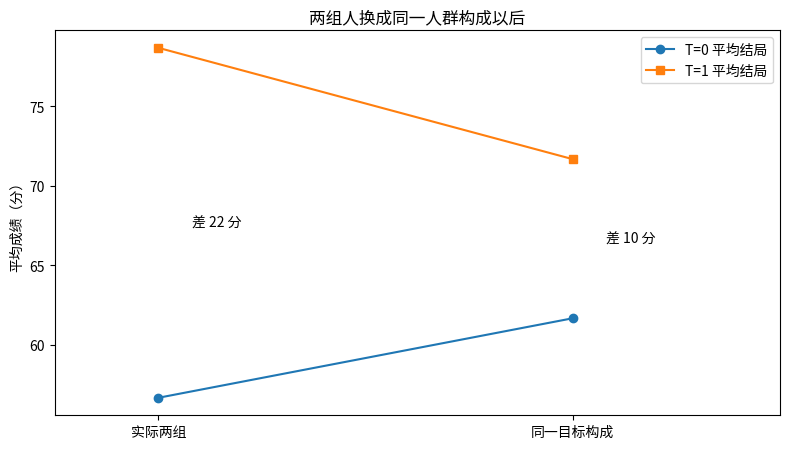

In [3]:
std_mean0 = np.average(toy["mean0"], weights=toy["全体权重"])
std_mean1 = np.average(toy["mean1"], weights=toy["全体权重"])
toy_ate = std_mean1 - std_mean0

toy_comparison = pd.DataFrame({
    "比较方式": ["实际两组：构成不同", "标准化：统一为全体构成"],
    "T=0 平均结局": [raw_mean0, std_mean0],
    "T=1 平均结局": [raw_mean1, std_mean1],
    "差值": [raw_mean1 - raw_mean0, toy_ate],
})
display(toy_comparison.round(4))

fig, ax = plt.subplots(figsize=(8, 4.6))
pos = np.arange(2)
ax.plot(pos, toy_comparison["T=0 平均结局"], "o-", label="T=0 平均结局")
ax.plot(pos, toy_comparison["T=1 平均结局"], "s-", label="T=1 平均结局")
for i, row in toy_comparison.iterrows():
    mid = (row["T=0 平均结局"] + row["T=1 平均结局"]) / 2
    ax.text(i + 0.08, mid, f"差 {row['差值']:.0f} 分", va="center")
ax.set(xticks=pos, xticklabels=["实际两组", "同一目标构成"],
       ylabel="平均成绩（分）", title="两组人换成同一人群构成以后")
ax.set_xlim(-0.25, 1.5)
ax.legend()
fig.tight_layout()
plt.show()

### 3. 用一个回归模型得到同样的结果

把三类 $X$ 当作类别，而不是假定从 0 到 1、从 1 到 2 的变化一样大。设 $I_1=I(X=1)$、$I_2=I(X=2)$，拟合：

$$
Y\sim 1+T+I_1+I_2+TI_1+TI_2.
$$

这个模型给六个“基础类别 × 处理状态”组合各自一个均值，因此可以重现六个层内观察均值。这里为每个组合构造均值恰好等于表中数值的一组教学记录，再用最小二乘拟合；这些记录不是从真实汇总资料恢复出的个体数据。

拟合完后，对全部 300 人各预测两次。下面先把计算展开，不急着封装函数。

In [4]:
records = []
for row in toy.itertuples(index=False):
    for treatment in (0, 1):
        count = int(getattr(row, f"n{treatment}"))
        group_mean = float(getattr(row, f"mean{treatment}"))
        offsets = np.linspace(-3, 3, count)
        outcomes = group_mean + offsets - offsets.mean()
        records.extend({"X": row.X, "T": treatment, "Y": value}
                       for value in outcomes)
toy_data = pd.DataFrame(records)

x_small = toy_data["X"].to_numpy()
t_small = toy_data["T"].to_numpy()
i1 = (x_small == 1).astype(float)
i2 = (x_small == 2).astype(float)
ones = np.ones(len(toy_data))
zeros = np.zeros(len(toy_data))

D = np.column_stack([ones, t_small, i1, i2, t_small * i1, t_small * i2])
beta_small, _, rank, _ = np.linalg.lstsq(D, toy_data["Y"], rcond=None)
assert rank == D.shape[1]

# 改 T 时，T 与类别的交互项也要随之重算。
D0 = np.column_stack([ones, zeros, i1, i2, zeros, zeros])
D1 = np.column_stack([ones, ones, i1, i2, i1, i2])
pred_small0 = D0 @ beta_small
pred_small1 = D1 @ beta_small
reg_ate_small = np.mean(pred_small1 - pred_small0)

display(pd.DataFrame({
    "X": x_small, "预测 T=0": pred_small0, "预测 T=1": pred_small1,
    "预测差值": pred_small1 - pred_small0,
}).groupby("X").first().round(4))
print(f"回归模型中的 T 系数：{beta_small[1]:.4f}")
print(f"逐人预测后的平均差：{reg_ate_small:.4f}")
print(f"分层标准化的平均差：{toy_ate:.4f}")
np.testing.assert_allclose(reg_ate_small, toy_ate, atol=1e-10)

,预测 T=0,预测 T=1,预测差值
X,,,
0,50.0,55.0,5.0
1,60.0,70.0,10.0
2,75.0,90.0,15.0


回归模型中的 T 系数：5.0000
逐人预测后的平均差：10.0000
分层标准化的平均差：10.0000


回归的 $T$ 系数为 5，对应参照类别 $X=0$ 的差值；逐人预测再平均得到 10，与分层标准化一致。并没有两种方法“打架”，只是回归系数和总体平均效应在回答不同的问题。

这个例子也解释了标准化与回归的联系：类别很少时，直接使用层内均值；变量连续或维度增加时，就借助模型估计条件均值，再做同样的平均。[1，第 10.4 节]

## 完整案例二：连续变量、非线性和交互项

### 1. 先写出数据生成规则

保留辅导与后续成绩的背景，但把基础指标 $X$ 改为连续变量。下面完全是教学设定，$Y$ 以任意单位计量，不限制在 0–100 分：

$$
\begin{aligned}
X&\sim\operatorname{Uniform}(-1,2),\\
e(X)&=0.15+0.70\left(\frac{X+1}{3}\right)^2,\\
T\mid X&\sim\operatorname{Bernoulli}(e(X)),\\
\mu_0(X)&=10+2X+3X^2,\\
\tau(X)&=2+1.5X+0.8X^2,\\
Y(t)&=\mu_0(X)+t\tau(X)+(1+0.4|X|)\varepsilon,
\qquad \varepsilon\sim N(0,1).
\end{aligned}
$$

生成处理的随机数与 $\varepsilon$ 独立。给定 $X$ 后没有剩余的共同原因；处理概率位于 0.15–0.85 之间。这些是本例可忽略性与重叠成立的依据，不是回归拟合出来的结论。[1，第 10.3.2 节]

本例两种潜在结局共用一个误差项，因而每个人的真实效应恰好等于 $\tau(X)$。这是为了便于核对而设的特殊模型，并不是回归调整必须满足的假设。

因为 $E[X]=0.5$、$E[X^2]=1$，总体 ATE 为：

$$
\tau=2+1.5\times0.5+0.8\times1=3.55.
$$

每次抽到的 $X_i$ 不完全一样，所以样本完整表的平均效应一般不恰好为 3.55。后面的重复模拟统一评价对总体 3.55 的估计误差。

In [5]:
def make_observational_data(n: int, seed: int):
    """生成观察数据，并将只能在模拟中知道的真值单独返回。"""
    if not isinstance(n, (int, np.integer)) or isinstance(n, bool) or n < 10:
        raise ValueError("n 需要是至少为 10 的整数。")
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 2, size=n)
    propensity = 0.15 + 0.70 * ((x + 1) / 3) ** 2
    t = rng.binomial(1, propensity)
    mu0 = 10 + 2 * x + 3 * x**2
    tau_x = 2 + 1.5 * x + 0.8 * x**2
    error = (1 + 0.4 * np.abs(x)) * rng.normal(size=n)
    y0 = mu0 + error
    y1 = mu0 + tau_x + error
    y = np.where(t == 1, y1, y0)
    observed = pd.DataFrame({"X": x, "T": t, "Y": y})
    truth = {
        "mu0": mu0, "mu1": mu0 + tau_x, "tau_x": tau_x,
        "y0": y0, "y1": y1, "propensity": propensity,
        "population_ate": 3.55,
    }
    return observed, truth

observed, truth = make_observational_data(N_MAIN, SEED_DATA)
x = observed["X"].to_numpy()
t = observed["T"].to_numpy()
y = observed["Y"].to_numpy()
TRUE_ATE = truth["population_ate"]

display(observed.head(8).round(4))
print(f"总体 ATE：{TRUE_ATE:.4f}")
print(f"本次样本完整表的平均效应：{truth['tau_x'].mean():.4f}")

,X,T,Y
0,1.3219,0,18.5683
1,0.3166,0,10.8663
2,1.5758,1,26.9717
3,1.0921,1,21.2983
4,-0.7175,0,9.1732
5,1.9269,1,32.9242
6,1.2834,1,22.2786
7,1.3582,1,21.3165


总体 ATE：3.5500
本次样本完整表的平均效应：3.5750


### 2. 看清楚实际两组的区别

先只读取观察数据，查看人数、基础指标与结局均值。图上两组都有数据，但它们在 $X$ 上的分布不同。重叠要求同类人有两种处理的可能，并不要求两组的边际分布完全相同。

,人数,X均值,X最小值,X最大值,Y均值,Y标准差
T,,,,,,
0,1106,0.2164,-0.9984,1.9958,12.3724,3.9076
1,694,0.9708,-0.9880,1.9983,21.4117,7.5350


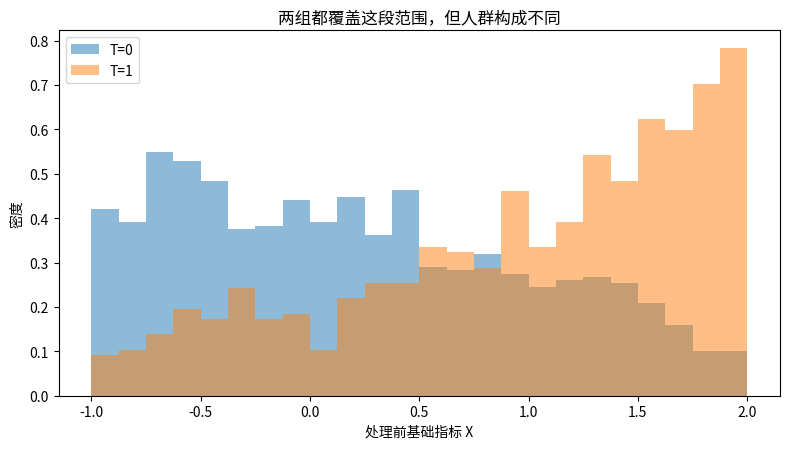

In [6]:
group_summary = observed.groupby("T").agg(
    人数=("Y", "size"), X均值=("X", "mean"),
    X最小值=("X", "min"), X最大值=("X", "max"),
    Y均值=("Y", "mean"), Y标准差=("Y", "std"),
)
display(group_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4.6))
bins = np.linspace(-1, 2, 25)
for treatment in (0, 1):
    ax.hist(x[t == treatment], bins=bins, density=True, alpha=0.5,
            label=f"T={treatment}")
ax.set(xlabel="处理前基础指标 X", ylabel="密度",
       title="两组都覆盖这段范围，但人群构成不同")
ax.legend()
fig.tight_layout()
plt.show()

### 3. 写好模型，再生成两份预测数据

比较四种预先指定的模型，不根据得到的效应大小临时增删项。

| 简称 | 设计矩阵中的列 | 对效应函数的限制 |
|---|---|---|
| 不调整 | $1,T$ | 忽略 $X$，作为基线 |
| 线性加性 | $1,T,X$ | 平均作用不随 $X$ 改变 |
| 二次加性 | $1,T,X,X^2$ | 基线可以弯曲，但平均作用仍不随 $X$ 改变 |
| 二次交互 | $1,T,X,X^2,TX,TX^2$ | 两种处理可以有不同的二次曲线 |

这里的二次模型对 $X$ 是非线性的，但对系数仍然线性，所以都能用最小二乘拟合。二次交互模型包含本例真实的条件均值；其他模型分别遗漏了某些项。这种比较是为了观察错设，不代表现实中提前知道该用哪个模型。[1，第 10.4.2 节；2，第 5.2 节]

先定义设计矩阵和拟合函数。修改 `T` 后重新调用 `design_matrix`，能够保证所有交互项同步改变。

In [7]:
MODEL_NAMES = {
    "raw": "不调整",
    "linear": "线性加性",
    "quadratic": "二次加性",
    "interactive": "二次交互",
}


def design_matrix(treatment, covariate, specification: str) -> np.ndarray:
    """本篇单个 X 的教学设计矩阵；treatment 可以是 0/1 或同长度数组。"""
    covariate = np.asarray(covariate, dtype=float)
    if covariate.ndim != 1 or covariate.size == 0 or not np.isfinite(covariate).all():
        raise ValueError("X 需要是非空、有限的一维数组。")
    treatment = np.asarray(treatment, dtype=float)
    if treatment.ndim == 0:
        treatment = np.full(covariate.shape, float(treatment))
    if treatment.shape != covariate.shape or not np.isin(treatment, [0, 1]).all():
        raise ValueError("T 需要为 0/1，并与 X 等长。")
    if specification not in MODEL_NAMES:
        raise ValueError(f"未知模型：{specification}")
    columns = [np.ones(covariate.size), treatment]
    if specification != "raw":
        columns.append(covariate)
    if specification in ("quadratic", "interactive"):
        columns.append(covariate**2)
    if specification == "interactive":
        columns.extend([treatment * covariate, treatment * covariate**2])
    return np.column_stack(columns)


def fit_ols(design, outcome) -> np.ndarray:
    """用最小二乘拟合；出现缺失、无穷或不满秩时停止，不悄悄丢数据。"""
    design = np.asarray(design, dtype=float)
    outcome = np.asarray(outcome, dtype=float)
    if design.ndim != 2 or outcome.ndim != 1 or len(outcome) != len(design):
        raise ValueError("设计矩阵与结局的形状不匹配。")
    if len(outcome) <= design.shape[1] or not (np.isfinite(design).all()
                                              and np.isfinite(outcome).all()):
        raise ValueError("样本数需大于参数数，且输入不能有缺失或无穷值。")
    coefficients, _, rank, _ = np.linalg.lstsq(design, outcome, rcond=None)
    if rank < design.shape[1]:
        raise ValueError("设计矩阵不满秩：检查两组人数、重复列或常量特征。")
    return coefficients

### 4. 对每个人预测两次

先把二次交互模型的全过程展开。拟合时只用真实的 `T, X, Y`；随后保留全体的 $X$，分别令 $T=0$ 和 $T=1$。

打印出的两列是条件均值预测，不是含有个体误差的潜在结局。`truth` 不参与拟合，只在最后评价时使用。

In [8]:
D_main = design_matrix(t, x, "interactive")
beta_main = fit_ols(D_main, y)

D_main0 = design_matrix(0, x, "interactive")
D_main1 = design_matrix(1, x, "interactive")
mu0_hat = D_main0 @ beta_main
mu1_hat = D_main1 @ beta_main
tau_hat_x = mu1_hat - mu0_hat

individual_predictions = observed.copy()
individual_predictions["预测 T=0"] = mu0_hat
individual_predictions["预测 T=1"] = mu1_hat
individual_predictions["预测差值"] = tau_hat_x
display(individual_predictions.head(8).round(4))
print(f"全体都取 T=0 时的预测均值：{mu0_hat.mean():.4f}")
print(f"全体都取 T=1 时的预测均值：{mu1_hat.mean():.4f}")
print(f"标准化 ATE：{tau_hat_x.mean():.4f}")
np.testing.assert_allclose(tau_hat_x.mean(), mu1_hat.mean() - mu0_hat.mean())

,X,T,Y,预测 T=0,预测 T=1,预测差值
0,1.3219,0,18.5683,17.8275,23.3177,5.4902
1,0.3166,0,10.8663,10.8991,13.5969,2.6978
2,1.5758,1,26.9717,20.5276,26.9386,6.4110
3,1.0921,1,21.2983,15.7145,20.4465,4.7319
4,-0.7175,0,9.1732,10.0375,11.2835,1.2460
5,1.9269,1,32.9242,24.8918,32.7190,7.8272
6,1.2834,1,22.2786,17.4521,22.8104,5.3584
7,1.3582,1,21.3165,18.1903,23.8069,5.6166


全体都取 T=0 时的预测均值：14.0107
全体都取 T=1 时的预测均值：17.6457
标准化 ATE：3.6350


### 5. 用同一种平均方式比较四个模型

四个模型都在同一份观察数据上拟合、对相同的全体 $X_i$ 求平均。`不调整` 行的两列预测均值恰好等于实际两组均值；其余行则是调整后的标准化均值。

下面的训练 RMSE 只是补充描述拟合情况。它不是因果效应误差，也不能用来证明识别假设；模型间的效应比较还要结合我们已经写明的生成机制。[2，第 5.2 节]

In [9]:
coefficients = {}
comparison_rows = []
for spec, label in MODEL_NAMES.items():
    D_fit = design_matrix(t, x, spec)
    beta = fit_ols(D_fit, y)
    coefficients[spec] = beta
    pred0 = design_matrix(0, x, spec) @ beta
    pred1 = design_matrix(1, x, spec) @ beta
    estimate = np.mean(pred1 - pred0)
    comparison_rows.append({
        "模型": label, "T系数": beta[1],
        "标准化均值 T=0": pred0.mean(), "标准化均值 T=1": pred1.mean(),
        "标准化ATE": estimate, "与总体真值之差": estimate - TRUE_ATE,
        "训练RMSE": np.sqrt(np.mean((y - D_fit @ beta)**2)),
    })
model_comparison = pd.DataFrame(comparison_rows).set_index("模型")
display(model_comparison.round(4))

# 不含 X 的模型退化为实际两组均值差。
np.testing.assert_allclose(
    model_comparison.loc["不调整", "标准化ATE"],
    y[t == 1].mean() - y[t == 0].mean(), atol=1e-10,
)

,T系数,标准化均值 T=0,标准化均值 T=1,标准化ATE,与总体真值之差,训练RMSE
模型,,,,,,
不调整,9.0392,12.3724,21.4117,9.0392,5.4892,5.5886
线性加性,4.5362,14.1086,18.6448,4.5362,0.9862,2.9909
二次加性,3.8634,14.3680,18.2314,3.8634,0.3134,1.6104
二次交互,2.1002,14.0107,17.6457,3.6350,0.0850,1.3481


默认数据中，不调整的差值约为 9.04；线性加性模型约为 4.54，二次加性模型约为 3.86，二次交互模型约为 3.64。总体真值是 3.55。加入 $X$ 有帮助，但只把变量名称放进模型，仍没有完整表达曲率和效应异质性。

一次接近真值不等于方法总能成功。稍后会重新生成很多份数据，区分抽样波动与系统性偏差。

### 6. 把两种处理下的曲线画出来

图中散点来自观察结局，实线与虚线分别表示指定的真实条件均值和拟合的条件均值。真实曲线只在这个模拟中可用；在真实研究里不能按这种方式直接检查反事实预测。

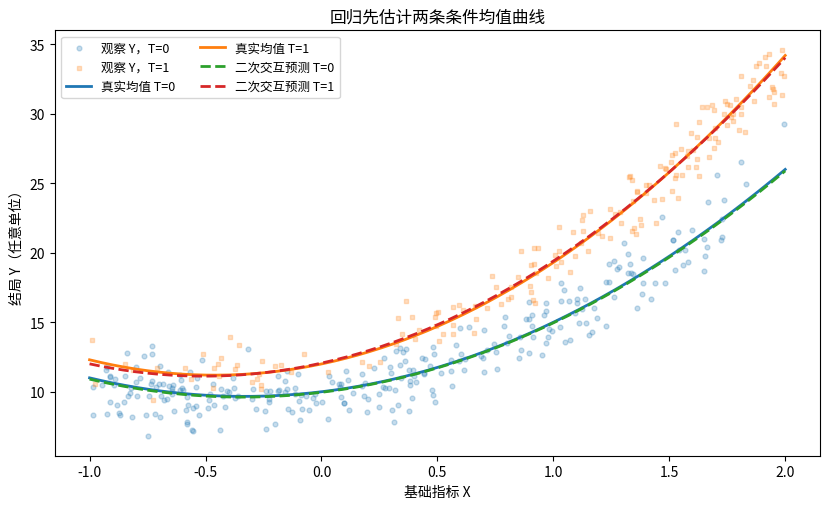

In [10]:
x_grid = np.linspace(-1, 2, 180)
true_mu0_grid = 10 + 2 * x_grid + 3 * x_grid**2
true_tau_grid = 2 + 1.5 * x_grid + 0.8 * x_grid**2
true_mu1_grid = true_mu0_grid + true_tau_grid

fig, ax = plt.subplots(figsize=(8.4, 5.2))
# 只抽稀显示散点，模型仍用全部 N_MAIN 人拟合。
for treatment, marker in [(0, "o"), (1, "s")]:
    shown = np.flatnonzero(t == treatment)[::4]
    ax.scatter(x[shown], y[shown], s=12, alpha=0.25, marker=marker,
               label=f"观察 Y，T={treatment}")
ax.plot(x_grid, true_mu0_grid, linewidth=2, label="真实均值 T=0")
ax.plot(x_grid, true_mu1_grid, linewidth=2, label="真实均值 T=1")
ax.plot(x_grid, design_matrix(0, x_grid, "interactive") @ beta_main,
        "--", linewidth=2, label="二次交互预测 T=0")
ax.plot(x_grid, design_matrix(1, x_grid, "interactive") @ beta_main,
        "--", linewidth=2, label="二次交互预测 T=1")
ax.set(xlabel="基础指标 X", ylabel="结局 Y（任意单位）",
       title="回归先估计两条条件均值曲线")
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

再把两条曲线相减。加性模型无论基线拟合得多弯曲，处理差值都只能是一条水平线；交互模型才允许差值随 $X$ 改变。

这里暂不把重点放在学习个体化模型上，只用这张图解释：忽略交互，可能连总体平均效应也估计不好。系统的异质性学习与验证留到后面的因果机器学习部分。

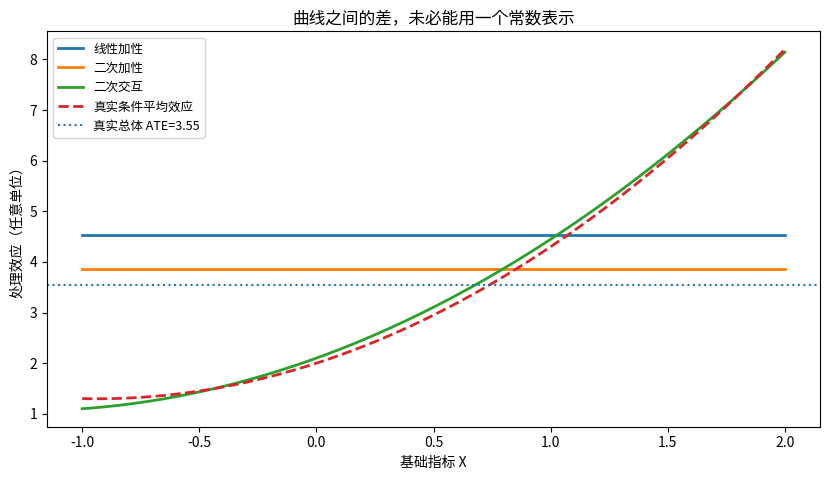

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 4.9))
for spec in ("linear", "quadratic", "interactive"):
    beta = coefficients[spec]
    grid_effect = (design_matrix(1, x_grid, spec)
                   - design_matrix(0, x_grid, spec)) @ beta
    ax.plot(x_grid, grid_effect, linewidth=2, label=MODEL_NAMES[spec])
ax.plot(x_grid, true_tau_grid, "--", linewidth=2, label="真实条件平均效应")
ax.axhline(TRUE_ATE, linestyle=":", linewidth=1.5, label="真实总体 ATE=3.55")
ax.set(xlabel="基础指标 X", ylabel="处理效应（任意单位）",
       title="曲线之间的差，未必能用一个常数表示")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 7. 中心化以后，为什么处理系数变成了 ATE？

二次交互模型的处理差值为：

$$
\widehat\tau(x)=\widehat\beta_T+\widehat\beta_{TX}x
+\widehat\beta_{TX^2}x^2.
$$

令 $W_1=X-\bar X$、$W_2=X^2-\overline{X^2}$，再拟合 $1,T,W_1,W_2,TW_1,TW_2$。由于目标样本中两个 $W$ 的平均值都为 0，新的处理系数就是标准化效应。[1，第 10.4.2 节；2，第 5.2 节]

不要只把 $X$ 中心化后再平方，并以为二次项也均值为零。下面同时核对“平均特征处的预测差”；它与逐人平均并不是同一个量。

In [12]:
w1 = x - x.mean()
w2 = x**2 - np.mean(x**2)
D_centered = np.column_stack([np.ones(len(x)), t, w1, w2, t * w1, t * w2])
beta_centered = fit_ols(D_centered, y)

average_by_formula = (beta_main[1] + beta_main[4] * x.mean()
                      + beta_main[5] * np.mean(x**2))
x_mean = np.array([x.mean()])
effect_at_mean_x = float(((design_matrix(1, x_mean, "interactive")
                          - design_matrix(0, x_mean, "interactive")) @ beta_main)[0])

centering_check = pd.DataFrame({
    "计算": ["未中心化的 T 系数（X=0）", "先逐人预测，再平均",
             "按系数公式计算平均", "分别中心化 X 和 X² 后的 T 系数",
             "只在平均 X 处计算预测差"],
    "结果": [beta_main[1], tau_hat_x.mean(), average_by_formula,
             beta_centered[1], effect_at_mean_x],
})
display(centering_check.round(6))

np.testing.assert_allclose(D_centered @ beta_centered, D_main @ beta_main, atol=1e-10)
np.testing.assert_allclose(
    [average_by_formula, beta_centered[1]], tau_hat_x.mean(), atol=1e-10
)
# 最后一行与标准化的差别，来自 beta_TX² × Var_n(X)。
np.testing.assert_allclose(
    tau_hat_x.mean() - effect_at_mean_x,
    beta_main[5] * np.var(x, ddof=0), atol=1e-10,
)

,计算,结果
0,未中心化的 T 系数（X=0）,2.100224
1,先逐人预测，再平均,3.635013
2,按系数公式计算平均,3.635013
3,分别中心化 X 和 X² 后的 T 系数,3.635013
4,只在平均 X 处计算预测差,3.122784


中间三种算法数值相同，拟合值也没有改变。中心化只是让回归表里的一个系数恰好对应所选人群的平均效应。

最后一行则少算了二次项的分布信息。更一般地，非线性函数先取平均再代入，与先代入再取平均通常不同。这里的差别由本例公式精确算出，不是数值舍入问题。

### 8. 分别拟合两个组，结果一样吗？

完全交互模型允许两组分别有各自的截距、一次项和二次项。它也可以改写成：对照组单独拟合 $\widehat\mu_0(X)$，处理组单独拟合 $\widehat\mu_1(X)$，最后仍对全体 $X_i$ 求平均。[1，第 10.4.2 节]

下面只核对这个代数关系；不额外增加一种“更高级”的估计器。

In [13]:
B_x = np.column_stack([np.ones(len(x)), x, x**2])
beta0_separate = fit_ols(B_x[t == 0], y[t == 0])
beta1_separate = fit_ols(B_x[t == 1], y[t == 1])
separate_mu0 = B_x @ beta0_separate
separate_mu1 = B_x @ beta1_separate

print(f"完全交互回归的 ATE：{tau_hat_x.mean():.8f}")
print(f"两组分别拟合的 ATE：{np.mean(separate_mu1 - separate_mu0):.8f}")
print(f"T=0 预测最大差：{np.max(np.abs(separate_mu0 - mu0_hat)):.2e}")
print(f"T=1 预测最大差：{np.max(np.abs(separate_mu1 - mu1_hat)):.2e}")
np.testing.assert_allclose(separate_mu0, mu0_hat, atol=1e-10)
np.testing.assert_allclose(separate_mu1, mu1_hat, atol=1e-10)

完全交互回归的 ATE：3.63501318
两组分别拟合的 ATE：3.63501318
T=0 预测最大差：1.78e-14
T=1 预测最大差：2.13e-14


## 进一步分析

### 1. 误差范围：整行重抽样，每次重新拟合

回归调整的效应是模型参数和目标人群构成共同计算出来的量。不能把 $\widehat\tau(X_i)$ 的标准差除以 $\sqrt n$，就当作最终效应的标准误；那样没有完整计入拟合两个条件均值的误差。

Ding 第 10.4.2 节建议使用非参数 Bootstrap 估计标准误。本篇按附录 A.6 的独立同分布总体设定，重抽样完整的 $(X_i,T_i,Y_i)$ 记录。每次都重新拟合回归，并对该次重抽样的 $X_i^*$ 求平均，得到 $\widehat\tau_b^*$。这样连样本构成的变化也一起重放。[1，第 10.4.2 节、附录 A.6]

$$
\widehat{\mathrm{SE}}_{\mathrm{boot}}
=\sqrt{\frac{1}{B-1}\sum_{b=1}^{B}
(\widehat\tau_b^*-\bar\tau^*)^2},\qquad
\bar\tau^*=\frac1B\sum_{b=1}^{B}\widehat\tau_b^*.
$$

沿用书中的正态近似区间：

$$
\widehat\tau_{\mathrm{reg}}
\pm z_{0.975}\widehat{\mathrm{SE}}_{\mathrm{boot}}.
$$

这不是随机化检验，也不是把处理标签打乱。它近似估计器的抽样波动；模型错设或遗漏混杂造成的系统偏差，不会因为重抽样就消失。这里为低维、预先指定的回归模型做区间演示，不将它无条件推广为任何机器学习算法都适用的推断方法。

In [14]:
def regression_summary(covariate, treatment, outcome, specification: str):
    """拟合后，对输入样本本身的 X 做标准化；只返回平均效应。"""
    D_fit = design_matrix(treatment, covariate, specification)
    beta = fit_ols(D_fit, outcome)
    contrast = (design_matrix(1, covariate, specification)
                - design_matrix(0, covariate, specification))
    return float(np.mean(contrast @ beta))


def bootstrap_regression(covariate, treatment, outcome, repeats: int, seed: int):
    """按完整的 IID 行重抽样；各模型共用每次的行索引。"""
    covariate = np.asarray(covariate, dtype=float)
    treatment = np.asarray(treatment)
    outcome = np.asarray(outcome, dtype=float)
    if (covariate.ndim != 1 or covariate.size == 0
            or treatment.shape != covariate.shape or outcome.shape != covariate.shape):
        raise ValueError("X、T、Y 需要是等长的非空一维数组。")
    if not isinstance(repeats, (int, np.integer)) or isinstance(repeats, bool) or repeats < 2:
        raise ValueError("Bootstrap 重复次数至少为 2。")
    rng = np.random.default_rng(seed)
    draws = np.empty((repeats, len(MODEL_NAMES)))
    for b in range(repeats):
        index = rng.integers(0, len(outcome), size=len(outcome))
        xb, tb, yb = covariate[index], treatment[index], outcome[index]
        for j, spec in enumerate(MODEL_NAMES):
            # 一旦出现单一处理组或不满秩，fit_ols 会报错；不静默丢弃该次重抽样。
            draws[b, j] = regression_summary(xb, tb, yb, spec)
    return pd.DataFrame(draws, columns=list(MODEL_NAMES.values()))

In [15]:
boot_draws = bootstrap_regression(x, t, y, N_BOOT, SEED_BOOT)
bootstrap_table = model_comparison[["标准化ATE"]].copy()
bootstrap_table["Bootstrap标准误"] = boot_draws.std(ddof=1)
bootstrap_table["95%区间下限"] = (bootstrap_table["标准化ATE"]
                               - Z_CRIT * bootstrap_table["Bootstrap标准误"])
bootstrap_table["95%区间上限"] = (bootstrap_table["标准化ATE"]
                               + Z_CRIT * bootstrap_table["Bootstrap标准误"])
bootstrap_table["本次是否含真值"] = (
    (bootstrap_table["95%区间下限"] <= TRUE_ATE)
    & (bootstrap_table["95%区间上限"] >= TRUE_ATE)
)
print(f"实际完成 {len(boot_draws)} 次整行 Bootstrap；模型在每次重抽样中重新拟合。")
display(bootstrap_table.round(4))

实际完成 999 次整行 Bootstrap；模型在每次重抽样中重新拟合。


,标准化ATE,Bootstrap标准误,95%区间下限,95%区间上限,本次是否含真值
模型,,,,,
不调整,9.0392,0.3116,8.4285,9.6500,False
线性加性,4.5362,0.1446,4.2529,4.8195,False
二次加性,3.8634,0.0944,3.6785,4.0484,False
二次交互,3.6350,0.0816,3.4750,3.7950,True


表中最后一列只描述这一次数据的区间，不能把一个 True 当成“覆盖率已经验证为 95%”。模型正确时，区间仍依赖大样本近似；模型错误时，窄区间也可能围绕错误的目标。

下面为了看清调整模型之间的差别，只画后三个模型的 Bootstrap 分布。不调整的结果已经保留在表中，未从计算里删除。

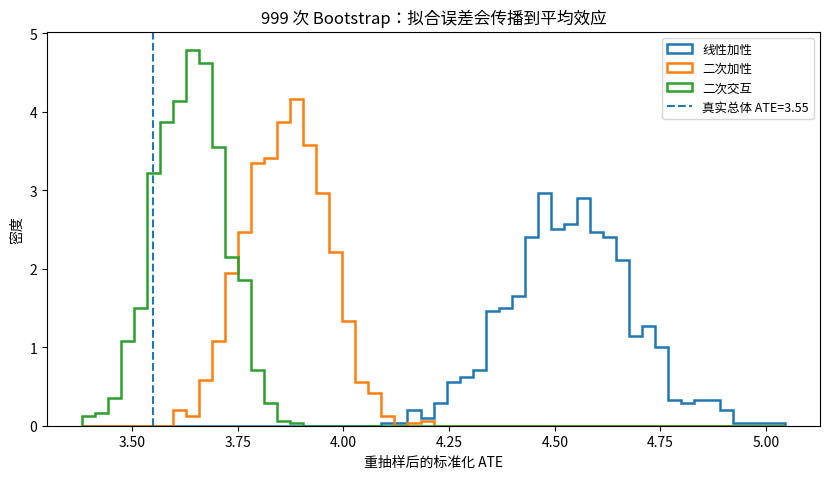

In [16]:
adjusted_labels = [MODEL_NAMES[s] for s in ("linear", "quadratic", "interactive")]
shown_boot = boot_draws[adjusted_labels]
boot_bins = np.linspace(shown_boot.min().min(), shown_boot.max().max(), 55)
fig, ax = plt.subplots(figsize=(8.4, 4.9))
for label in adjusted_labels:
    ax.hist(boot_draws[label], bins=boot_bins, density=True,
            histtype="step", linewidth=1.8, label=label)
ax.axvline(TRUE_ATE, linestyle="--", linewidth=1.5, label="真实总体 ATE=3.55")
ax.set(xlabel="重抽样后的标准化 ATE", ylabel="密度",
       title=f"{N_BOOT} 次 Bootstrap：拟合误差会传播到平均效应")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 2. 换很多份数据，区分偏差与随机波动

现在与 Bootstrap 不同：不是从同一份观察数据重抽样，而是每次按写好的总体模型，重新生成 $X,T,Y$。每个样本量做 500 次，比较平均估计、偏差、经验标准差和 RMSE。

$$
\widehat{\mathrm{Bias}}
=\frac1R\sum_{r=1}^R\widehat\tau_r-\tau,
\qquad
\widehat{\mathrm{RMSE}}
=\sqrt{\frac1R\sum_{r=1}^R(\widehat\tau_r-\tau)^2}.
$$

这组实验是依据结果回归的模型错设问题另行设计的，不是复写原书的一张结果表。我们关心：样本增多以后，哪些结果向 3.55 集中，哪些只是更稳定地停留在偏离 3.55 的位置。[1，第 10.4.2 节；2，第 5.2 节]

In [17]:
repeat_rng = np.random.default_rng(SEED_REPEAT)
repeat_records = []
for n in SAMPLE_SIZES:
    for repetition in range(N_REPEATS):
        seed = int(repeat_rng.integers(0, 2**32 - 1))
        sample, _ = make_observational_data(n, seed)
        xr = sample["X"].to_numpy()
        tr = sample["T"].to_numpy()
        yr = sample["Y"].to_numpy()
        for spec, label in MODEL_NAMES.items():
            estimate = regression_summary(xr, tr, yr, spec)
            repeat_records.append({
                "n": n, "重复": repetition, "模型": label, "ATE估计": estimate,
            })
repeated = pd.DataFrame(repeat_records)

repeat_rows = []
for n in SAMPLE_SIZES:
    for label in MODEL_NAMES.values():
        estimates = repeated.loc[(repeated["n"] == n) & (repeated["模型"] == label),
                                 "ATE估计"].to_numpy()
        sd = estimates.std(ddof=1)
        repeat_rows.append({
            "n": n, "模型": label, "重复次数": len(estimates),
            "平均估计": estimates.mean(), "偏差": estimates.mean() - TRUE_ATE,
            "经验标准差": sd, "RMSE": np.sqrt(np.mean((estimates - TRUE_ATE)**2)),
            "偏差的MC标准误": sd / np.sqrt(len(estimates)),
        })
repeat_summary = pd.DataFrame(repeat_rows)
display(repeat_summary.round(4))

,n,模型,重复次数,平均估计,偏差,经验标准差,RMSE,偏差的MC标准误
0,300,不调整,500,8.7783,5.2283,0.7440,5.2809,0.0333
1,300,线性加性,500,4.4387,0.8887,0.3580,0.9580,0.0160
2,300,二次加性,500,3.7560,0.2060,0.2369,0.3137,0.0106
3,300,二次交互,500,3.5343,-0.0157,0.2081,0.2085,0.0093
4,1200,不调整,500,8.7971,5.2471,0.3830,5.2610,0.0171
5,1200,线性加性,500,4.4523,0.9023,0.1882,0.9217,0.0084
6,1200,二次加性,500,3.7712,0.2212,0.1252,0.2541,0.0056
7,1200,二次交互,500,3.5547,0.0047,0.1041,0.1041,0.0047
8,4800,不调整,500,8.8175,5.2675,0.1835,5.2707,0.0082
9,4800,线性加性,500,4.4567,0.9067,0.0889,0.9110,0.0040


“经验标准差”描述一份研究数据的估计有多不稳定；“偏差的 MC 标准误”描述有限次模拟对平均偏差的计算有多精确。两者不要混用。

图中仍只展示三个调整模型，点为模拟偏差，误差棒为估计量的正负一个经验标准差。它不是均值的置信区间，也不是某一份研究的效应区间。

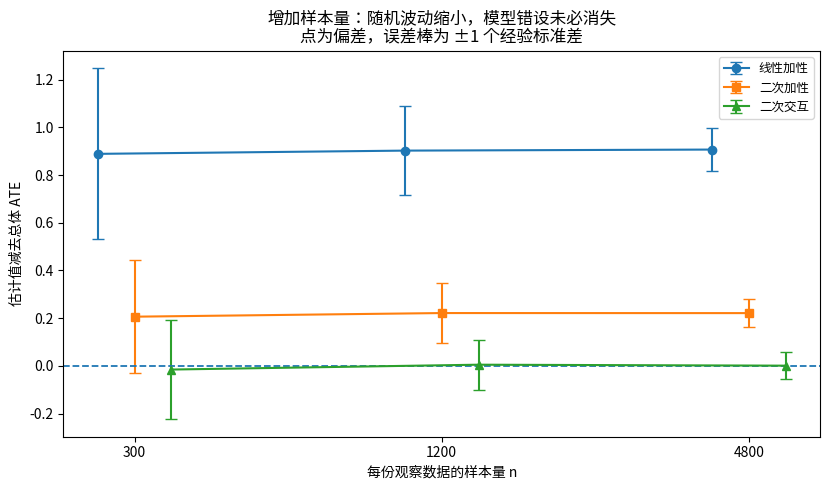

In [18]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))
positions = np.arange(len(SAMPLE_SIZES))
for offset, label, marker in zip((-0.12, 0.0, 0.12), adjusted_labels, ("o", "s", "^")):
    rows = repeat_summary[repeat_summary["模型"] == label].set_index("n").loc[list(SAMPLE_SIZES)]
    ax.errorbar(positions + offset, rows["偏差"], yerr=rows["经验标准差"],
                marker=marker, linestyle="-", capsize=4, linewidth=1.5, label=label)
ax.axhline(0, linestyle="--", linewidth=1.3)
ax.set(xticks=positions, xticklabels=[str(n) for n in SAMPLE_SIZES],
       xlabel="每份观察数据的样本量 n", ylabel="估计值减去总体 ATE",
       title="增加样本量：随机波动缩小，模型错设未必消失\n点为偏差，误差棒为 ±1 个经验标准差")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

在本例中，正确包含二次项和交互项的模型围绕真值波动；两个加性模型的随机波动随样本量增加而缩小，但偏差仍然保留。尤其是二次加性模型已经纳入了 $X^2$，仍然没有允许效应随 $X$ 改变。

这里不是证明“所有复杂模型都比简单模型好”。这个结果依赖我们明确指定的生成机制与候选模型。若真实均值本来就是加性的，多余参数也会带来估计误差；第一个练习之后可以自行删去生成公式中的异质性项再试。

## 结果分析

到这里，可以把两个不同层次的问题分开：

| 问题 | 本篇怎么检查 | 不能由什么替代 |
|---|---|---|
| 为什么可以调整这些变量？ | 沿用上一份的因果结构与识别条件 | 回归的显著性或训练误差 |
| 平均的是哪群人？ | 明确预测时保留的 $X$ 和平均权重 | 不加说明地只读处理系数 |
| 条件均值模型是否合适？ | 本例用已知真值、曲线与重复模拟核对 | 只看一个接近真值的结果 |
| 误差范围有多大？ | 整行 Bootstrap，每次重新拟合和平均 | 把一列拟合差值当作独立观测效应 |

观察性研究没有自动得到随机试验的保护。选对调整变量与拟合好条件均值，两件事都重要。即使模型能输出任意 $X$ 下的预测，低重叠区域仍可能主要依赖外推；Bootstrap 也不会凭空增加那里缺少的对照。[1，第 10.3–10.4 节；2，第 5.2 节]

## 练习

### 1. 模型不变，只改成估计 ATT，会发生什么？

本篇一直对全体的 $X$ 求平均。现在目标换成已经接受处理的人，按相同的两条拟合曲线，对 $T_i=1$ 的人求平均：

$$
\widehat\tau_{\mathrm{ATT}}
=\frac1{n_1}\sum_{i:T_i=1}
\{\widehat\mu_1(X_i)-\widehat\mu_0(X_i)\}.
$$

对本例完全交互 OLS，由于处理组内有独立截距，处理组的平均拟合残差为零。因此，它还等于：

$$
\frac1{n_1}\sum_{i:T_i=1}
\{Y_i-\widehat\mu_0(X_i)\}.
$$

第二种写法正是 Ding 第 13.1 节的结果回归 ATT 估计。一般学习器的两种样本算法不一定数值相等；这里的相等来自本例 OLS 的组内残差性质。[1，第 13.1 节；2，第 5.5 节]

先猜一下本例 ATT 比 ATE 大还是小，再运行下面的代码。右边的“本次目标样本真值”只作模拟核对，不参与左边的估计。

In [19]:
target_masks = {
    "全体（ATE）": np.ones(len(x), dtype=bool),
    "已处理者（ATT）": t == 1,
    "未处理者（ATC）": t == 0,
}
target_rows = []
for label, mask in target_masks.items():
    target_rows.append({
        "平均人群": label, "人数": mask.sum(), "X均值": x[mask].mean(),
        "标准化估计": tau_hat_x[mask].mean(),
        "本次目标样本真值": truth["tau_x"][mask].mean(),
    })
target_table = pd.DataFrame(target_rows)
display(target_table.round(4))

att_predicted = tau_hat_x[t == 1].mean()
att_observed_minus_predicted = np.mean(y[t == 1] - mu0_hat[t == 1])
print(f"ATT：两列预测相减 = {att_predicted:.6f}")
print(f"ATT：实际处理结局减预测对照结局 = {att_observed_minus_predicted:.6f}")
np.testing.assert_allclose(att_predicted, att_observed_minus_predicted, atol=1e-10)
np.testing.assert_allclose(
    tau_hat_x.mean(),
    t.mean() * att_predicted + (1 - t.mean()) * tau_hat_x[t == 0].mean(),
    atol=1e-10,
)

,平均人群,人数,X均值,标准化估计,本次目标样本真值
0,全体（ATE）,1800,0.5073,3.6350,3.5750
1,已处理者（ATT）,694,0.9708,4.7902,4.7207
2,未处理者（ATC）,1106,0.2164,2.9101,2.8562


ATT：两列预测相减 = 4.790206
ATT：实际处理结局减预测对照结局 = 4.790206


本例较高的 $X$ 更容易接受处理，效应在这部分人中也整体较大，因此 ATT 高于全体平均。这不是换了模型后“效应变大”，而是平均的人群变了。

表中各子样本的真值也有抽样波动，不能直接当作总体 ATT、ATC 的已知常数。作为代数核对，全体平均应等于按实际人数比例加权的两个子组平均；代码最后已经验证这一点。

### 2. 二元结局：Logistic 的系数是不是平均效应？

现在把结局改为“是否通过考试”。另设：

$$
\begin{aligned}
X&\sim\operatorname{Uniform}(-1,2),\\
P(T=1\mid X)&=0.2+0.6\frac{X+1}{3},\\
P(Y(t)=1\mid X)&=\operatorname{expit}(-1+0.8t+1.2X),\\
\operatorname{expit}(a)&=\frac{1}{1+\exp(-a)}.
\end{aligned}
$$

生成处理和结局的随机数相互独立。这个模型符合 Ding 例 10.4 的 Logistic 形式，参数和数据是另设的。本题目标是通过概率的平均差，也就是二元结局的 ATE，而不是优势比。[1，第 10.4.2 节、附录 B.6]

在这个不含交互的 logit 模型中，$\beta_T=0.8$ 表示条件 log OR，$\exp(\beta_T)$ 才是条件 OR。但我们要的仍是：

$$
\widehat\tau
=\frac1n\sum_i\left[
\operatorname{expit}(\widehat\beta_0+\widehat\beta_T+\widehat\beta_X X_i)
-\operatorname{expit}(\widehat\beta_0+\widehat\beta_X X_i)
\right].
$$

先按设定生成数据。两项潜在结局只用于核对观察结局的生成；回归仍然只读取 `X, T, Y`。

In [20]:
def expit(value):
    """稳定地计算 Logistic 概率；不直接对很大的正数取指数。"""
    value = np.asarray(value, dtype=float)
    return np.exp(-np.logaddexp(0.0, -value))


rng_binary = np.random.default_rng(SEED_BINARY)
n_binary = 4000
xb = rng_binary.uniform(-1, 2, size=n_binary)
tb = rng_binary.binomial(1, 0.2 + 0.6 * (xb + 1) / 3)
prob0 = expit(-1 + 1.2 * xb)
prob1 = expit(-1 + 0.8 + 1.2 * xb)
yb0 = rng_binary.binomial(1, prob0)
yb1 = rng_binary.binomial(1, prob1)
yb = np.where(tb == 1, yb1, yb0)
binary_data = pd.DataFrame({"X": xb, "T": tb, "Y": yb})

display(binary_data.groupby("T").agg(
    人数=("Y", "size"), X均值=("X", "mean"), 通过比例=("Y", "mean")
).round(4))

# 只为教学计算总体真值：对已知的概率函数作 Gauss-Legendre 数值积分。
# X=(3u+1)/2 将 [-1,1] 映射到 [-1,2]；均匀分布期望的权重为 weights/2。
quad_nodes, quad_weights = np.polynomial.legendre.leggauss(80)
x_integral = (3 * quad_nodes + 1) / 2
binary_population_ate = float(np.sum(quad_weights * (
    expit(-1 + 0.8 + 1.2 * x_integral) - expit(-1 + 1.2 * x_integral)
)) / 2)
print(f"本题总体 ATE（通过概率差）：{binary_population_ate:.6f}")
print(f"也就是提高 {100 * binary_population_ate:.3f} 个百分点。")

,人数,X均值,通过比例
T,,,
0,2002,0.1974,0.3521
1,1998,0.7713,0.6406


本题总体 ATE（通过概率差）：0.158148
也就是提高 15.815 个百分点。


用 statsmodels 的二项 GLM 拟合 Logistic 回归。它负责求系数；两次预测、目标人群平均都仍在下面几行代码中完成。设计矩阵已经包含截距，不再额外重复添加。[3，GLM 与 predict 接口文档]

In [21]:
import statsmodels
import statsmodels.api as sm

print(f"statsmodels {statsmodels.__version__}")
D_binary = design_matrix(tb, xb, "linear")
binary_fit = sm.GLM(yb, D_binary, family=sm.families.Binomial()).fit()
if not binary_fit.converged:
    raise RuntimeError("Logistic 模型未收敛，请检查输入和拟合诊断。")

pb0_hat = binary_fit.predict(design_matrix(0, xb, "linear"))
pb1_hat = binary_fit.predict(design_matrix(1, xb, "linear"))
binary_ate_hat = float(np.mean(pb1_hat - pb0_hat))
xb_mean = np.array([xb.mean()])
binary_at_mean = float((
    binary_fit.predict(design_matrix(1, xb_mean, "linear"))
    - binary_fit.predict(design_matrix(0, xb_mean, "linear"))
)[0])

binary_results = pd.DataFrame({
    "计算": ["处理系数", "exp(处理系数)", "实际两组通过比例差",
             "逐人预测后平均", "平均 X 处的概率差", "模拟总体真值"],
    "值": [binary_fit.params[1], np.exp(binary_fit.params[1]),
           yb[tb == 1].mean() - yb[tb == 0].mean(),
           binary_ate_hat, binary_at_mean, binary_population_ate],
    "尺度": ["条件 log OR", "条件 OR", "概率差", "概率差", "概率差", "概率差"],
})
display(binary_results.round(6))
print(f"全体的标准化通过比例：T=0 时 {pb0_hat.mean():.2%}；T=1 时 {pb1_hat.mean():.2%}")
print(f"标准化平均提高：{100 * binary_ate_hat:.3f} 个百分点。")

statsmodels 0.14.6


,计算,值,尺度
0,处理系数,0.725765,条件 log OR
1,exp(处理系数),2.066311,条件 OR
2,实际两组通过比例差,0.288493,概率差
3,逐人预测后平均,0.144788,概率差
4,平均 X 处的概率差,0.179465,概率差
5,模拟总体真值,0.158148,概率差


全体的标准化通过比例：T=0 时 42.40%；T=1 时 56.88%
标准化平均提高：14.479 个百分点。


Logistic 在 log odds 尺度上是加性的，但通过概率的差随 $X$ 改变。因此，即使没有加入交互项，也仍然需要逐人计算两次概率，再平均。

下面画真实与估计的条件概率差。两条水平线分别对应“逐人平均”和“平均 $X$ 处预测”；它们不是同一个量。这个例子也提醒我们：二元处理是从 0 切换到 1，应计算两次预测的有限差，而不是把对连续变量求导的公式直接搬过来。[1，例 10.4]

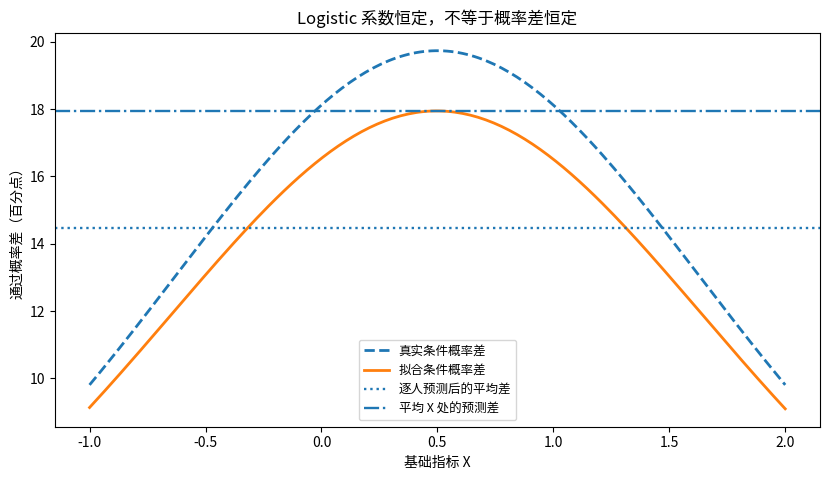

In [22]:
binary_grid = np.linspace(-1, 2, 180)
true_risk_difference = (expit(-1 + 0.8 + 1.2 * binary_grid)
                        - expit(-1 + 1.2 * binary_grid))
predicted_risk_difference = (
    binary_fit.predict(design_matrix(1, binary_grid, "linear"))
    - binary_fit.predict(design_matrix(0, binary_grid, "linear"))
)
fig, ax = plt.subplots(figsize=(8.4, 4.9))
ax.plot(binary_grid, 100 * true_risk_difference, "--", linewidth=2,
        label="真实条件概率差")
ax.plot(binary_grid, 100 * predicted_risk_difference, linewidth=2,
        label="拟合条件概率差")
ax.axhline(100 * binary_ate_hat, linestyle=":", linewidth=1.7,
           label="逐人预测后的平均差")
ax.axhline(100 * binary_at_mean, linestyle="-.", linewidth=1.7,
           label="平均 X 处的预测差")
ax.set(xlabel="基础指标 X", ylabel="通过概率差（百分点）",
       title="Logistic 系数恒定，不等于概率差恒定")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

一个尺度说明：上传版 Ding 正文第 148 页脚注 4 将 $\widehat\beta_T$ 写作条件 odds ratio；同书附录 B.6.1 的公式则明确给出“系数等于条件 odds ratio 的对数”。这里按该附录的定义区分 $\beta_T$ 与 $\exp(\beta_T)$，不把脚注文字直接用作计算公式。

## 总结

回归调整的计算可以归结为：先拟合条件均值，再为同一目标人群预测两种处理状态，最后汇总预测差。分层均值、完全交互回归和分别拟合两个组，都能按这个思路理解。

处理系数只有在特定模型和参数化下才等于平均效应。遇到交互项、非线性变换或二元结局，直接展开两次预测更不容易混淆。ATE 与 ATT 的区别也体现在最后平均的是哪群人。

模型正确与识别条件成立仍然是两回事。Bootstrap 描述抽样不确定性，但不会修复遗漏混杂或模型错设。下一篇从另一端入手：不先预测结局，而是研究谁更可能接受处理，介绍倾向评分与协变量平衡。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. arXiv:2305.18793v2，2023-10-03。对应上传文件 `因果推断.pdf`。主要使用第 10.3–10.4 节（正文第 142–149 页，调整公式、分层标准化、结果回归与二元结局）；另参考第 13.1 节（第 181–182 页，ATT 的结果回归）、附录 A.6（第 417–418 页，非参数 Bootstrap）和 B.6.1（第 427 页，Logistic 模型的系数尺度）。例如正文第 148 页对应上传 PDF 第 174 页。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. Version 0.1.2，2026-05-03。对应上传文件 `CausalML_book_2022.pdf`，以扉页版本为准。主要使用第 5.2 节（正文第 134–140 页，条件可忽略性、重叠、线性与交互模型）和第 5.5 节（第 145–146 页，分组效应及 ATET）。这里把该书中的处理符号 $D$ 与 Ding 中的 $Z$ 统一记为 $T$。

[3] 实现接口核对：NumPy 官方文档 `numpy.linalg.lstsq`；statsmodels 官方文档 `GLM`、`GLMResults.predict`。文档只用于核对最小二乘和二项 GLM 的调用；统计方法与假设依据前两项参考资料。实际执行环境版本打印在代码输出中。

三层成绩表、二次交互模型、样本量实验、二元结局模型及练习的具体参数均为依据上述内容另设的教学构造，不是两本书中的实证结论。中心化、分组拟合与目标人群加权的数值相等关系，由本篇设定直接作代数核对。图表全部来自当前代码，不是书中截图或预先填写的运行结果。